In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import time

In [2]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using: {device}")


Using: mps


In [3]:
R = 1.0
KAPPA = 1.0
EPS = 1

In [4]:
def r_norm(x,y,z):
    return torch.sqrt(x**2+y**2+z**2 + 1e-6)

def u_exact(x,y,z):
    r = r_norm(x,y,z)
    pi = torch.tensor(torch.pi, device=device)
    return torch.exp(-KAPPA*r)*torch.sin(pi*r)/r

def compute_laplacian(u,x,y,z):
    u_x = torch.autograd.grad(u,x,grad_outputs=torch.ones_like(u),create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x),create_graph=True, retain_graph=True)[0]

    u_y = torch.autograd.grad(u,y,grad_outputs=torch.ones_like(u),create_graph=True, retain_graph=True)[0]
    u_yy = torch.autograd.grad(u_y,y,grad_outputs=torch.ones_like(u_y),create_graph=True, retain_graph=True)[0]

    u_z = torch.autograd.grad(u,z,grad_outputs=torch.ones_like(u),create_graph=True, retain_graph=True)[0]
    u_zz = torch.autograd.grad(u_z,z,grad_outputs=torch.ones_like(u_z),create_graph=True, retain_graph=True)[0]
                            
    return u_xx + u_yy + u_zz

def source_term(x,y,z):
    x = x.detach().requires_grad_(True)
    y = y.detach().requires_grad_(True)
    z = z.detach().requires_grad_(True)

    u = u_exact(x,y,z)
    laplacian = compute_laplacian(u,x,y,z)

    with torch.no_grad():
        u_val = u_exact(x,y,z)
    return (-laplacian + KAPPA**2 * u_val).detach()

In [5]:
class LPB_PINN(nn.Module):
    def __init__(self, layers=[3,64,64,64,1]):
        super().__init__()

        network = []
        for i in range(len(layers)-1):
            network.append(nn.Linear(layers[i],layers[i+1]))
            if i<len(layers)-2:
                network.append(nn.Tanh())
        self.net = nn.Sequential(*network)

        for m in self.net:
            if isinstance(m,nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)


    def distance_fn(self,x,y,z):
        return R**2 - (x**2+y**2+z**2)

    def forward(self,x,y,z):
        inp = torch.cat([x,y,z],dim =1)
        N = self.net(inp)
        phi = self.distance_fn(x,y,z)
        u_bc = u_exact(x,y,z)

        return u_bc + N*phi

In [6]:
def compute_residual(model,x,y,z):
    u = model(x,y,z)

    laplacian = compute_laplacian(u,x,y,z)
    rho = source_term(x,y,z)

    return -laplacian + KAPPA**2*u - rho

In [7]:
def sample_interior(N):
    pts = []
    while sum(p.shape[0] for p in pts) < N :
        cands = torch.rand(int(N * 2.2), 3, device=device) * 2 - 1
        mask = (cands**2).sum(dim =1)<R**2
        pts.append(cands[mask])

    pts = torch.cat(pts)[:N]

    x   = pts[:, 0:1].requires_grad_(True)
    y   = pts[:, 1:2].requires_grad_(True)
    z   = pts[:, 2:3].requires_grad_(True)
    return x, y, z

def sample_surface(N):
    raw = torch.randn(N, 3, device=device)
    pts = R * raw / raw.norm(dim=1, keepdim=True)
    return pts[:, 0:1], pts[:, 1:2], pts[:, 2:3]

In [8]:
def compute_metrics(model,N=4000):
    with torch.no_grad():
        x,y,z = sample_interior(N)
        u_pred = model(x,y,z)
        u_true = u_exact(x,y,z)
        l2  = (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()
        max_err  = torch.max(torch.abs(u_pred - u_true)).item()

    xs, ys, zs = sample_surface(500)
    with torch.no_grad():
        bc_viol = torch.max(
            torch.abs(model(xs, ys, zs) - u_exact(xs, ys, zs))
        ).item()

    return l2, max_err, bc_viol

In [ ]:
def train(model, n_epochs=10000, N_interior=3000, lr=1e-3, log_every=500):
    history = {
        'loss'       : [],
        'l2'         : [],
        'max_err'    : [],
        'bc_viol'    : [],
        'epoch_time' : [],
        'cum_time'   : [],
    }

    t_start = time.perf_counter()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5
    )

    for epoch in range(1, n_epochs + 1):
        t0 = time.perf_counter()

        model.train()
        optimizer.zero_grad()

        x, y, z = sample_interior(N_interior)
        loss = torch.mean(compute_residual(model, x, y, z)**2)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        t1 = time.perf_counter()
        history['loss'].append(loss.item())
        history['epoch_time'].append((t1 - t0) * 1000)

        if epoch % log_every == 0:
            model.eval()
            l2, max_err, bc_viol = compute_metrics(model)
            elapsed = time.perf_counter() - t_start

            history['l2'].append(l2)
            history['max_err'].append(max_err)
            history['bc_viol'].append(bc_viol)
            history['cum_time'].append(elapsed)

            avg_ms = np.mean(history['epoch_time'][-log_every:])

            print(f"{epoch:>8} | {loss.item():>10.2e} | {l2:>8.4f} | "
                  f"{max_err:>9.2e} | {bc_viol:>10.2e} | "
                  f"{avg_ms:>13.1f} | {elapsed:>10.1f}s")

    # ✅ These are NOW outside the for loop (no indentation under the for)
    total_time = time.perf_counter() - t_start
    print(f"\n  Total training time : {total_time:.1f}s  "
          f"({total_time/60:.2f} mins)")
    print(f"  Avg time per epoch  : "
          f"{np.mean(history['epoch_time']):.1f} ms")

    return history, total_time

In [10]:
def plot_results(model, history, total_time):

    N      = 150
    z_vals = [0.0, 0.5]

    fig = plt.figure(figsize=(20, 13))
    gs  = gridspec.GridSpec(3, 4, figure=fig,
                            hspace=0.45, wspace=0.38)

    # ── Solution slices ───────────────────────────────────────────────────
    for col, z_val in enumerate(z_vals):
        xy     = torch.linspace(-R, R, N, device=device)
        X2, Y2 = torch.meshgrid(xy, xy, indexing='ij')
        xf     = X2.reshape(-1, 1)
        yf     = Y2.reshape(-1, 1)
        zf     = torch.full_like(xf, z_val)
        inside = (xf**2 + yf**2 + zf**2 <= R**2).squeeze().cpu().numpy()

        with torch.no_grad():
            up = model(xf, yf, zf).squeeze().cpu().numpy()
            ut = u_exact(xf, yf, zf).squeeze().cpu().numpy()

        err = np.abs(up - ut)
        msk = lambda a: np.where(inside, a, np.nan)
        Xnp, Ynp = X2.cpu().numpy(), Y2.cpu().numpy()

        # Prediction
        ax = fig.add_subplot(gs[0, col*2])
        c  = ax.contourf(Xnp, Ynp, msk(up).reshape(N,N),
                         levels=40, cmap='RdBu_r')
        plt.colorbar(c, ax=ax)
        ax.set_title(f'Prediction  z={z_val}', fontweight='bold', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_aspect('equal')

        # Error
        ax2 = fig.add_subplot(gs[0, col*2+1])
        c2  = ax2.contourf(Xnp, Ynp, msk(err).reshape(N,N),
                           levels=40, cmap='hot_r')
        plt.colorbar(c2, ax=ax2)
        ax2.set_title(f'Error  z={z_val}', fontweight='bold', fontsize=10)
        ax2.set_xlabel('x'); ax2.set_ylabel('y')
        ax2.set_aspect('equal')

    # ── Loss curve ────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    ax3.semilogy(history['loss'], color='steelblue', lw=1.0, alpha=0.8)
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Residual Loss (log)')
    ax3.set_title('Training Loss — Vanilla 3D PINN', fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # ── L2 error convergence ──────────────────────────────────────────────
    eval_ep = [i * 500 for i in range(1, len(history['l2'])+1)]
    ax4 = fig.add_subplot(gs[1, 2:])
    ax4.semilogy(eval_ep, history['l2'],      'o-', label='L2 Relative', lw=2)
    ax4.semilogy(eval_ep, history['max_err'], 's-', label='Max Absolute', lw=2)
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Error (log)')
    ax4.set_title('Error Convergence', fontweight='bold')
    ax4.legend(); ax4.grid(True, alpha=0.3)

    # ── Time per epoch ────────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, :2])
    ax5.plot(history['epoch_time'], color='darkorange', lw=0.8, alpha=0.7)
    ax5.axhline(np.mean(history['epoch_time']), color='red',
                ls='--', lw=2,
                label=f"Mean: {np.mean(history['epoch_time']):.1f} ms/epoch")
    ax5.set_xlabel('Epoch'); ax5.set_ylabel('Time (ms)')
    ax5.set_title('Wall-Clock Time per Epoch', fontweight='bold')
    ax5.legend(); ax5.grid(True, alpha=0.3)

    # ── Cumulative time vs L2 error ───────────────────────────────────────
    ax6 = fig.add_subplot(gs[2, 2:])
    ax6.semilogy(history['cum_time'], history['l2'],
                 'D-', color='purple', lw=2, markersize=5)
    ax6.set_xlabel('Wall-clock time (s)')
    ax6.set_ylabel('L2 Relative Error (log)')
    ax6.set_title('Accuracy vs Real Time\n(key motivation for DD + Fourier)',
                  fontweight='bold')
    ax6.grid(True, alpha=0.3)

    plt.suptitle(
        f'Vanilla 3D LPB-PINN Baseline  —  '
        f'Total: {total_time:.0f}s  |  '
        f'Avg: {np.mean(history["epoch_time"]):.1f}ms/epoch\n'
        r'$-\nabla^2 u + \kappa^2 u = \rho$'
        f',  κ={KAPPA},  R={R}  |  No Fourier Features  |  No DD',
        fontsize=12, fontweight='bold'
    )

    plt.savefig('vanilla_lpb_pinn.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Final metrics
    l2, max_err, bc_viol = compute_metrics(model, N=6000)
    print(f"\n{'='*55}")
    print(f"  Final L2 Relative Error  : {l2:.6f}")
    print(f"  Final Max Absolute Error : {max_err:.6e}")
    print(f"  Final BC Violation       : {bc_viol:.6e}  ← machine precision")
    print(f"  Total Training Time      : {total_time:.1f}s")
    print(f"  Avg Time per Epoch       : "
          f"{np.mean(history['epoch_time']):.2f} ms")
    print(f"{'='*55}")

Model     : Vanilla 3D LPB-PINN (no Fourier, no DD)
Parameters: 12,801
PDE       : -∇²u + κ²u = ρ  on sphere r ≤ 1.0
κ         : 1.0  (Debye screening length inverse)
     500 |   3.55e-05 |   0.0003 |  6.57e-04 |   5.10e-10 |          25.1 |       16.7s
    1000 |   3.83e-07 |   0.0000 |  4.05e-05 |   2.86e-11 |          19.8 |       29.9s
    1500 |   3.66e-07 |   0.0000 |  4.83e-05 |   3.91e-11 |          19.9 |       43.4s
    2000 |   2.01e-07 |   0.0000 |  3.27e-05 |   1.88e-11 |          22.6 |       57.7s
    2500 |   3.92e-06 |   0.0001 |  1.71e-04 |   9.97e-11 |          20.1 |       71.1s
    3000 |   1.24e-04 |   0.0003 |  5.75e-04 |   2.32e-10 |          19.8 |       84.5s
    3500 |   2.18e-07 |   0.0000 |  4.09e-05 |   2.76e-11 |          19.8 |       97.8s
    4000 |   2.71e-05 |   0.0003 |  5.58e-04 |   4.18e-10 |          24.2 |      113.0s
    4500 |   2.40e-05 |   0.0003 |  6.61e-04 |   2.97e-10 |          35.9 |      132.8s
    5000 |   1.54e-06 |   0.0001 |  1.57e

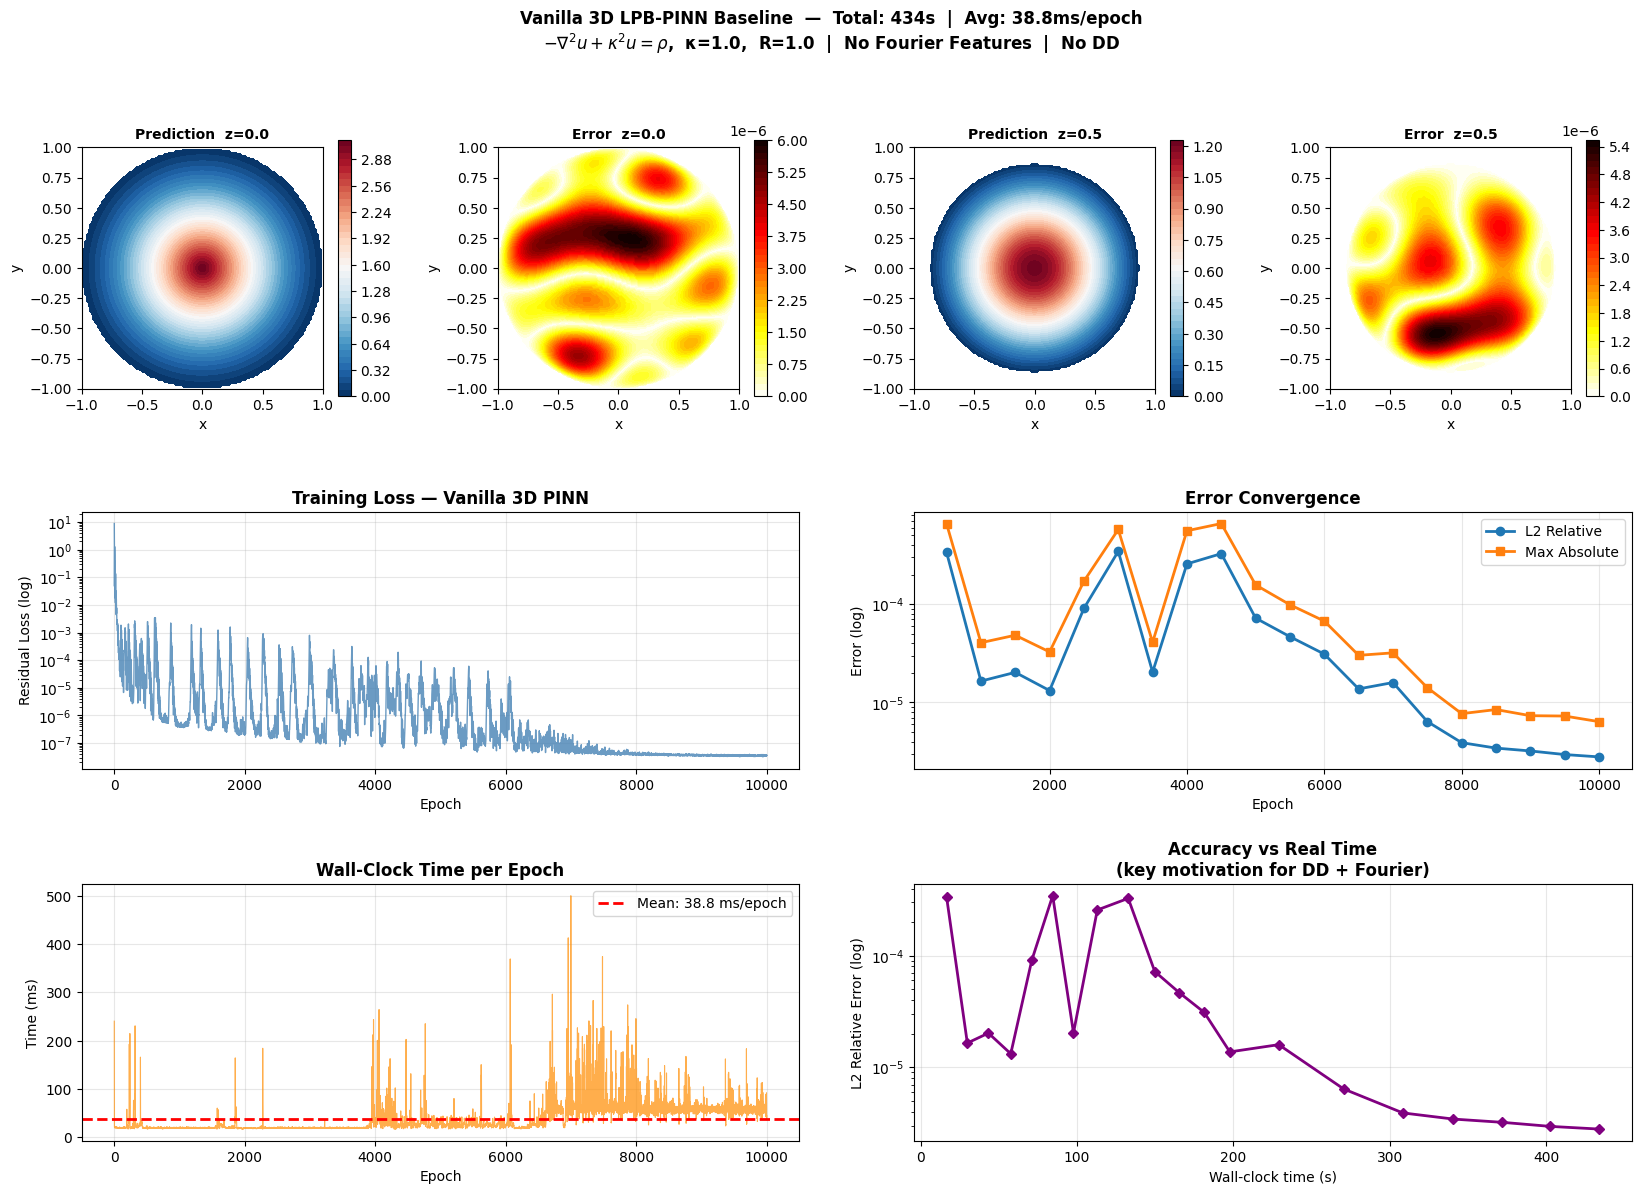


  Final L2 Relative Error  : 0.000003
  Final Max Absolute Error : 6.377697e-06
  Final BC Violation       : 8.327561e-12  ← machine precision
  Total Training Time      : 433.8s
  Avg Time per Epoch       : 38.76 ms


In [11]:
if __name__ == "__main__":

    model  = LPB_PINN(layers=[3, 64, 64, 64, 64, 1]).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f"Model     : Vanilla 3D LPB-PINN (no Fourier, no DD)")
    print(f"Parameters: {params:,}")
    print(f"PDE       : -∇²u + κ²u = ρ  on sphere r ≤ {R}")
    print(f"κ         : {KAPPA}  (Debye screening length inverse)")

    history, total_time = train(
        model,
        n_epochs   = 10000,
        N_interior = 3000,
        lr         = 1e-3,
        log_every  = 500
    )

    plot_results(model, history, total_time)